# AML s26 - K-Means Clustering


### Load libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

np.random.seed(42)

### Generate data
We create 3 obvious clusters using `make_blobs` with no labels!

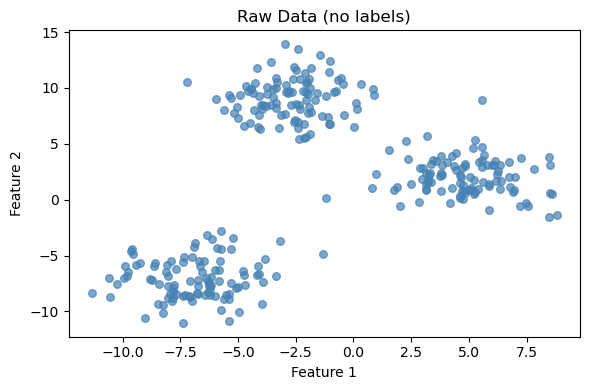

In [2]:
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.8, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.7, color='steelblue')
plt.title('Raw Data (no labels)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

### Fit K-Means
Let the algorithm find **k = 3** clusters

In [3]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42) 
# kmeans = KMeans(n_clusters=3, init='random', random_state=42)

kmeans.fit(X)

labels     = kmeans.labels_          # cluster assignment for each point
centers    = kmeans.cluster_centers_ # coordinates of the 3 centroids

print('Cluster counts:', np.bincount(labels))
print('Centroids:\n', centers.round(2))

Cluster counts: [100 100 100]
Centroids:
 [[-2.73  9.07]
 [-6.89 -7.07]
 [ 4.83  2.04]]


c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


### Visualize the result

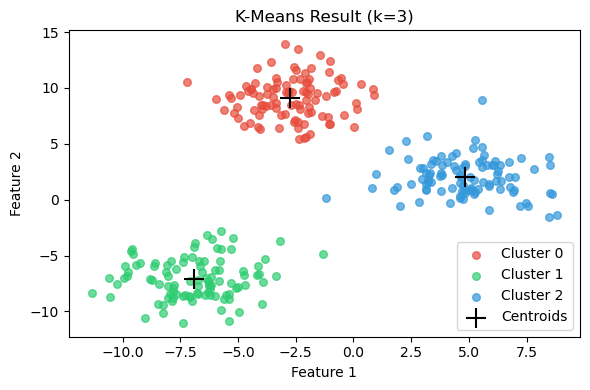

In [4]:
colors = ['#e74c3c', '#2ecc71', '#3498db']

plt.figure(figsize=(6, 4))
for k in range(3):
    mask = labels == k
    plt.scatter(X[mask, 0], X[mask, 1], s=30, alpha=0.7,
                color=colors[k], label=f'Cluster {k}')

plt.scatter(centers[:, 0], centers[:, 1],
            s=200, marker='+', color='black', zorder=5, label='Centroids')

plt.title('K-Means Result (k=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

### Choosing k — The Elbow Method
Run k-means for k = 1 … 8 and plot the **inertia** (sum of squared distances to the nearest centroid). 
The 'elbow' suggests the best k.

c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

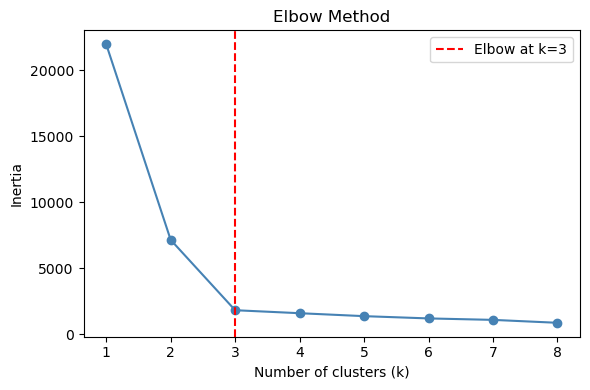

In [5]:
inertias = []
k_range  = range(1, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, 'o-', color='steelblue')
plt.axvline(3, color='red', linestyle='--', label='Elbow at k=3')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

### Silhouette Score
The **silhouette score** measures how well each point fits its own cluster vs. neighbouring clusters. 

Ranges from -1 (bad) to +1 (perfect).

c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

Best k by silhouette: 3  (score = 0.729)


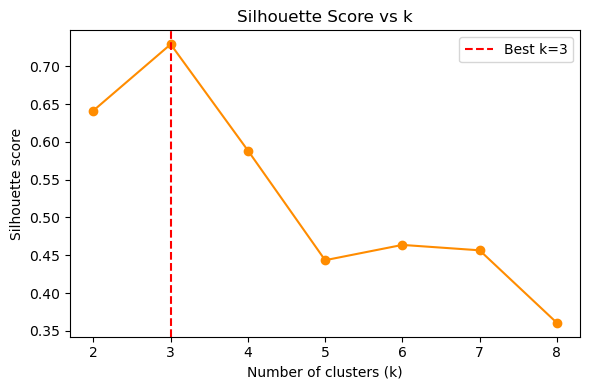

In [6]:
scores = []
k_range2 = range(2, 9)  # silhouette needs at least 2 clusters

for k in k_range2:
    km  = KMeans(n_clusters=k, random_state=42)
    lbl = km.fit_predict(X)
    scores.append(silhouette_score(X, lbl))

best_k = k_range2[np.argmax(scores)]
print(f'Best k by silhouette: {best_k}  (score = {max(scores):.3f})')

plt.figure(figsize=(6, 4))
plt.plot(k_range2, scores, 'o-', color='darkorange')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.legend()
plt.tight_layout()
plt.show()

### Predict new points

In [7]:
new_points = np.array([[0, 0], [5, 5], [-3, 6]])
predictions = kmeans.predict(new_points)

for point, cluster in zip(new_points, predictions):
    print(f'Point {point}  →  Cluster {cluster}')

Point [0 0]  →  Cluster 2
Point [5 5]  →  Cluster 2
Point [-3  6]  →  Cluster 0
